<a href="https://colab.research.google.com/github/Jaya-323/Python_practice/blob/main/Practice5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Importation successfull")

Importation successfull


In [28]:
!pip install kaggle

In [29]:
import kagglehub
path=kagglehub.dataset_download("shambhurajejagadale/student-performance-prediction-dataset")
print(path)

Using Colab cache for faster access to the 'student-performance-prediction-dataset' dataset.
/kaggle/input/student-performance-prediction-dataset


In [30]:
import os
print(os.listdir(path))

['student_dataset_10000_rows.csv']


In [31]:
csv_path=path+"/student_dataset_10000_rows.csv"
df=pd.read_csv(csv_path)
print(df.head())

   study_hours  attendance  sleep_hours  internet_usage  \
0            7          56            8               7   
1            4          69            5               3   
2           11          60            7               6   
3            8          99            9               8   
4            5          52            8               6   

   assignments_completed  previous_score  exam_score placement_status  
0                     10              62      100.00           Placed  
1                      8              56      100.00           Placed  
2                     10              45      100.00           Placed  
3                      4              55       90.17           Placed  
4                      8              40       78.82           Placed  


In [32]:
print(df.columns)

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')


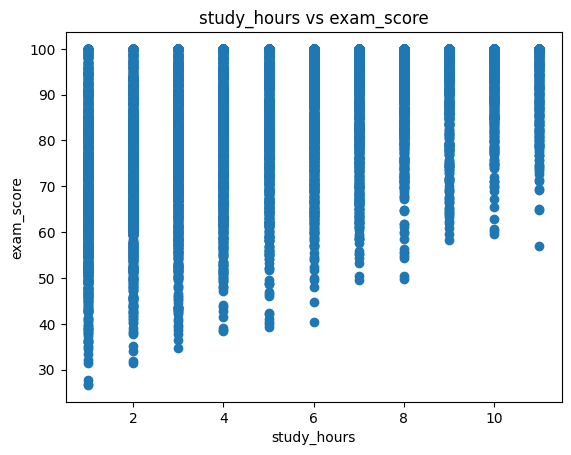

In [33]:
plt.scatter(df["study_hours"],df['exam_score'])
plt.xlabel("study_hours")
plt.ylabel("exam_score")
plt.title("study_hours vs exam_score")
plt.show()


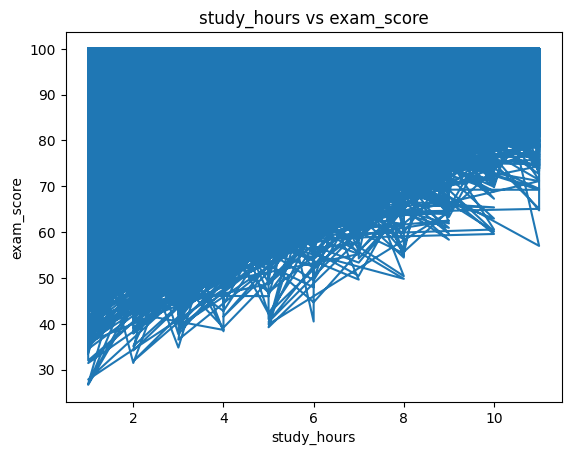

In [34]:
plt.plot(df["study_hours"],df['exam_score'])
plt.xlabel("study_hours")
plt.ylabel("exam_score")
plt.title("study_hours vs exam_score")
plt.show()

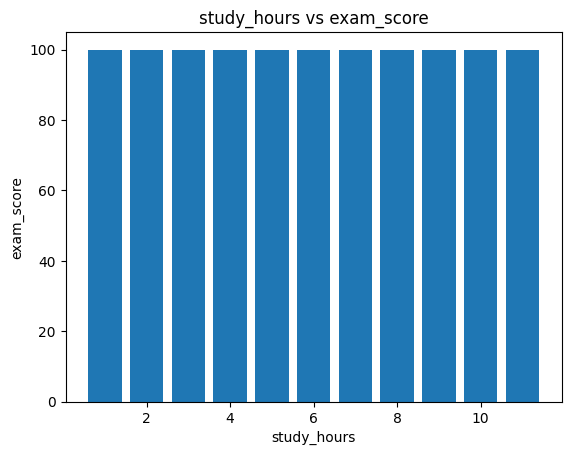

In [12]:
plt.bar(df["study_hours"],df['exam_score'])
plt.xlabel("study_hours")
plt.ylabel("exam_score")
plt.title("study_hours vs exam_score")
plt.show()

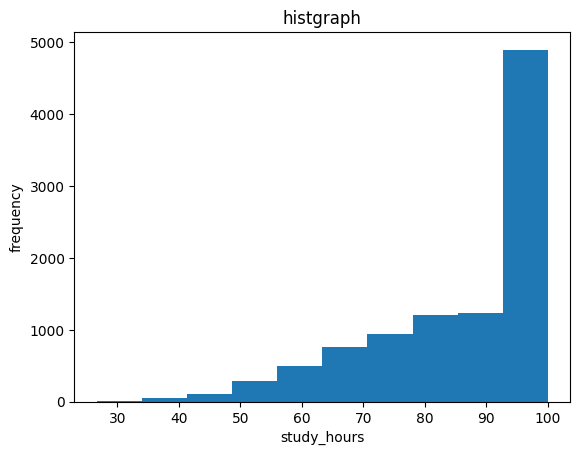

In [35]:
plt.hist(df['exam_score'])
plt.xlabel("study_hours")
plt.ylabel("frequency")
plt.title("histgraph")
plt.show()


In [36]:
df.drop("placement_status",axis=1,inplace=True)
print(df)

      study_hours  attendance  sleep_hours  internet_usage  \
0               7          56            8               7   
1               4          69            5               3   
2              11          60            7               6   
3               8          99            9               8   
4               5          52            8               6   
...           ...         ...          ...             ...   
9995            2          58            9               7   
9996            7          98            6               9   
9997           10          44            8               5   
9998           10          75            7               5   
9999            2          70            6              11   

      assignments_completed  previous_score  exam_score  
0                        10              62      100.00  
1                         8              56      100.00  
2                        10              45      100.00  
3                      

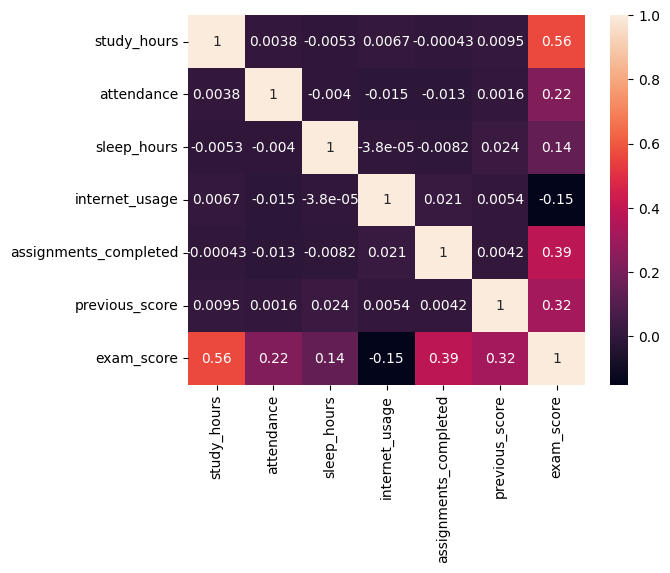

In [37]:
sns.heatmap(df.corr(),annot=True)
plt.show()


In [19]:
X=df.drop("exam_score",axis=1)
y=df["exam_score"]
print(X)
print(y)

      study_hours  attendance  sleep_hours  internet_usage  \
0               7          56            8               7   
1               4          69            5               3   
2              11          60            7               6   
3               8          99            9               8   
4               5          52            8               6   
...           ...         ...          ...             ...   
9995            2          58            9               7   
9996            7          98            6               9   
9997           10          44            8               5   
9998           10          75            7               5   
9999            2          70            6              11   

      assignments_completed  previous_score  
0                        10              62  
1                         8              56  
2                        10              45  
3                         4              55  
4                        

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

      study_hours  attendance  sleep_hours  internet_usage  \
9254           11          58            5               7   
1561           11          93            4              10   
1670            7          86            7               5   
6087            3          53            4               4   
6669           10          98            4               4   
...           ...         ...          ...             ...   
5734           11          67            4               8   
5191            7          96            9               7   
5390            9          91            4              10   
860             1          71            5               2   
7270            1          79            9               2   

      assignments_completed  previous_score  
9254                      5              70  
1561                      0              83  
1670                     14              85  
6087                      6              68  
6669                     

In [39]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
print("Model trained successfully")


Model trained successfully


In [40]:
prediction=model.predict(X_test)
print(prediction)

[104.48363625  86.34312059  88.7366549  ...  87.00882764 104.92516087
  73.08656223]


In [41]:
comparision=pd.DataFrame({"Actual":y_test,"Predicted":prediction})
print(comparision)

      Actual   Predicted
6252  100.00  104.483636
4684   84.07   86.343121
1731   95.37   88.736655
4742   83.96   76.233686
4521   78.58   91.130564
...      ...         ...
6412   69.44   70.503136
8285  100.00   87.416015
7853   96.35   87.008828
1095  100.00  104.925161
6929   69.79   73.086562

[2000 rows x 2 columns]


In [42]:
from sklearn.metrics import mean_absolute_error
error=mean_absolute_error(y_test,prediction)
print(error)

6.917285717910665


In [46]:
new_prediction=model.predict([[1,50,8,1,10,50]])
print(new_prediction)


[71.54730744]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
